# Predicting Subscriber Churn in a Music Streaming Platform

## Project Summary

This project analyzes customer behavior in a music streaming platform to predict subscriber churn and identify the strongest drivers of retention. I explored account-level and behavioral features, then compared a balanced logistic regression model with a random forest classifier to evaluate churn prediction performance.

## Business Problem

Subscriber churn is a major challenge for music streaming platforms because losing existing users can directly reduce recurring revenue and long-term growth. The goal of this project is to identify which users are most at risk of churning and translate those findings into actionable retention recommendations.

## Dataset Overview

The dataset contains 41,000 customer records and 20 variables describing subscriber demographics, account structure, platform behavior, and churn status. The target variable is `churned`, where 1 indicates that the customer churned and 0 indicates that the customer was retained.

## Project Workflow

This project follows four main steps:

1. Inspect and prepare the dataset  
2. Explore churn patterns through EDA  
3. Train and compare churn prediction models  
4. Translate findings into business recommendations

## Data Inspection and Preparation

The dataset was first inspected for structure, data types, missing values, and duplicates before feature preparation began.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import matplotlib.pyplot as plt

In [4]:
!pip install -q kagglehub pandas

In [5]:
import kagglehub
import os

path = kagglehub.dataset_download("daliado98/music-streaming-customer-churn-dataset")
print("Path to dataset files:", path)
print("Files:", os.listdir(path))

100%|██████████| 1.81M/1.81M [00:00<00:00, 38.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/daliado98/music-streaming-customer-churn-dataset/versions/1
Files: ['train.csv', 'sample_submission.csv', 'test.csv']


## Initial Data Checks

In [6]:
import pandas as pd
train_path = os.path.join(path, "train.csv")
df = pd.read_csv(train_path)
df.head()

,customer_id,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned
0,1,72,Washington,family premium,monthly,monthly,venmo,many,4/8/2014,17.953071,2.453398,0.04,245,151,35,57,14,7,0,0
1,2,48,New York,family premium,annual,monthly,credit,none,12/10/2015,7.725493,0.924008,0.98,112,57,18,62,10,3,1,0
2,3,76,West Virginia,family premium,annual,annual,credit,few,4/22/2014,9.514800,1.563817,0.35,124,96,15,34,17,6,1,0
3,4,80,Georgia,family premium,annual,annual,debit,few,8/31/2013,8.497869,1.089721,0.69,130,109,13,42,8,4,0,0
4,5,39,New Jersey,family premium,annual,annual,debit,many,1/14/2013,29.971731,2.313365,0.76,490,293,54,90,14,5,0,0


In [7]:
print(df.shape)
print(df.columns.tolist())

(41000, 20)
['customer_id', 'age', 'location', 'subscription_type', 'payment_plan', 'num_subscription_pauses', 'payment_method', 'customer_service_inquiries', 'signup_date', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'churned']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41000 entries, 0 to 40999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 41000 non-null  int64  
 1   age                         41000 non-null  int64  
 2   location                    41000 non-null  object 
 3   subscription_type           41000 non-null  object 
 4   payment_plan                41000 non-null  object 
 5   num_subscription_pauses     41000 non-null  object 
 6   payment_method              41000 non-null  object 
 7   customer_service_inquiries  41000 non-null  object 
 8   signup_date                 41000 non-null  object 
 9   weekly_hours                41000 non-null  float64
 10  average_session_length      41000 non-null  float64
 11  song_skip_rate              41000 non-null  float64
 12  weekly_songs_played         41000 non-null  int64  
 13  weekly_unique_songs         410

In [9]:
df["churned"].value_counts()

,count
churned,
0,32253
1,8747


In [10]:
df["churned"].value_counts(normalize=True)

,proportion
churned,
0,0.786659
1,0.213341


In [11]:
df.isnull().sum()

,0
customer_id,0
age,0
location,0
subscription_type,0
payment_plan,0
num_subscription_pauses,0
payment_method,0
customer_service_inquiries,0
signup_date,0
weekly_hours,0


In [12]:
df.isnull().sum().sort_values(ascending=False)

,0
customer_id,0
age,0
location,0
subscription_type,0
payment_plan,0
num_subscription_pauses,0
payment_method,0
customer_service_inquiries,0
signup_date,0
weekly_hours,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Create a working copy
df_clean = df.copy()

# Convert signup_date to datetime
df_clean["signup_date"] = pd.to_datetime(df_clean["signup_date"])

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41000 entries, 0 to 40999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 41000 non-null  int64         
 1   age                         41000 non-null  int64         
 2   location                    41000 non-null  object        
 3   subscription_type           41000 non-null  object        
 4   payment_plan                41000 non-null  object        
 5   num_subscription_pauses     41000 non-null  object        
 6   payment_method              41000 non-null  object        
 7   customer_service_inquiries  41000 non-null  object        
 8   signup_date                 41000 non-null  datetime64[ns]
 9   weekly_hours                41000 non-null  float64       
 10  average_session_length      41000 non-null  float64       
 11  song_skip_rate              41000 non-null  float64   

In [15]:
print("Earliest signup date:", df_clean["signup_date"].min())
print("Latest signup date:", df_clean["signup_date"].max())

Earliest signup date: 2013-01-01 00:00:00
Latest signup date: 2022-02-15 00:00:00


In [16]:
# Create customer tenure in days
latest_date = df_clean["signup_date"].max()
df_clean["tenure_days"] = (latest_date - df_clean["signup_date"]).dt.days

df_clean[["signup_date", "tenure_days"]].head()

,signup_date,tenure_days
0,2014-04-08,2870
1,2015-12-10,2259
2,2014-04-22,2856
3,2013-08-31,3090
4,2013-01-14,3319


## Exploratory Data Analysis

The exploratory analysis focused on identifying which account and behavioral variables appeared most related to churn. I compared churn patterns across subscription structure, payment behavior, and engagement-related features to understand which signals were most informative.

churned
0    15.420589
1    15.327844
Name: weekly_hours, dtype: float64


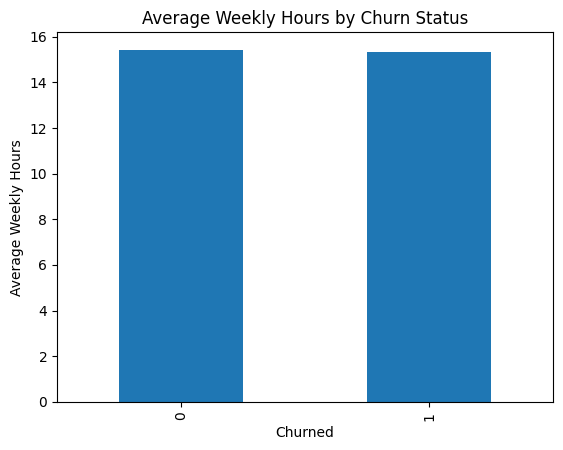

In [17]:
# Average weekly hours by churn status
weekly_hours_by_churn = df_clean.groupby("churned")["weekly_hours"].mean()

print(weekly_hours_by_churn)

weekly_hours_by_churn.plot(kind="bar")

plt.title("Average Weekly Hours by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Average Weekly Hours")

plt.show()

churned
0    1.522009
1    1.491033
Name: average_session_length, dtype: float64


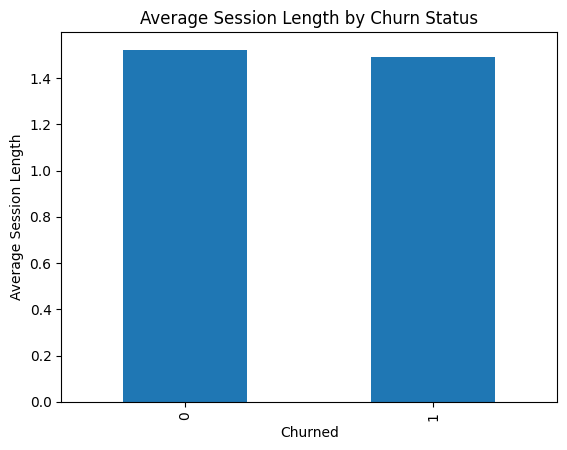

In [18]:
# Average session length by churn status
session_length_by_churn = df_clean.groupby("churned")["average_session_length"].mean()

print(session_length_by_churn)

session_length_by_churn.plot(kind="bar")

plt.title("Average Session Length by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Average Session Length")

plt.show()

subscription_type
student           0.324395
premium           0.258145
basic             0.188192
family premium    0.178420
Name: churned, dtype: float64


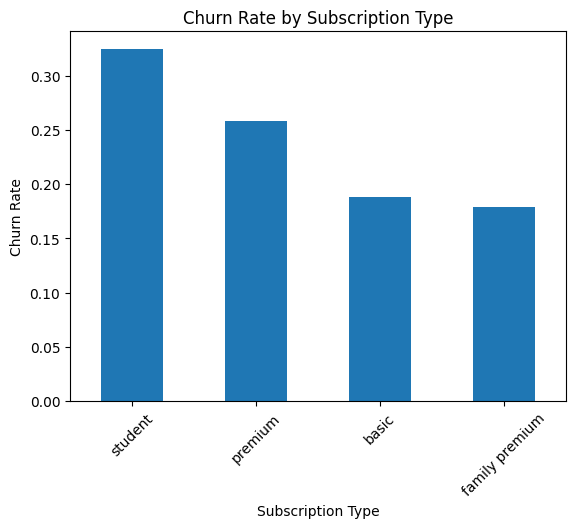

In [19]:
# Churn rate by subscription type
churn_by_subscription = df_clean.groupby("subscription_type")["churned"].mean().sort_values(ascending=False)

print(churn_by_subscription)

churn_by_subscription.plot(kind="bar")

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate")

plt.xticks(rotation=45)

plt.show()

## Early Insight 1

Churn differs substantially by subscription type. Student users had the highest churn rate at about 32.4%, followed by premium users at 25.8%. Basic and family premium users showed lower churn rates, suggesting that subscription structure may be more informative than simple listening volume when explaining retention.

payment_plan
monthly    0.368837
annual     0.154490
Name: churned, dtype: float64


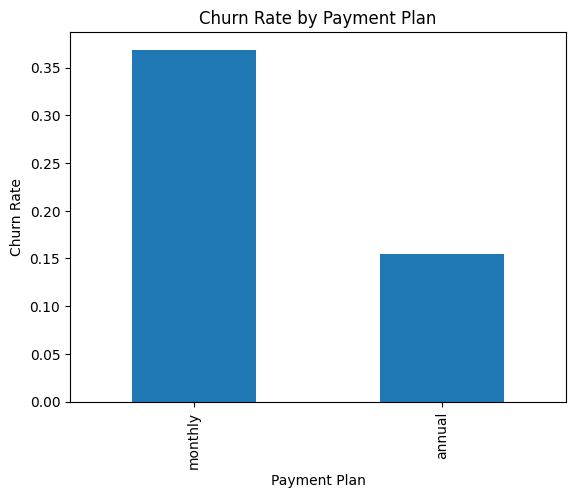

In [20]:
# Churn rate by payment plan
churn_by_payment_plan = df_clean.groupby("payment_plan")["churned"].mean().sort_values(ascending=False)

print(churn_by_payment_plan)

churn_by_payment_plan.plot(kind="bar")

plt.title("Churn Rate by Payment Plan")
plt.xlabel("Payment Plan")
plt.ylabel("Churn Rate")

plt.show()

## Early Insight 2

Payment plan shows a large difference in churn. Monthly users had a churn rate of about 36.9%, compared with 15.4% for annual users. This suggests that billing structure and commitment length are strongly associated with retention, and that monthly subscribers may be an especially important segment for churn prevention efforts.

churned
0    0.374763
1    0.380828
Name: song_skip_rate, dtype: float64


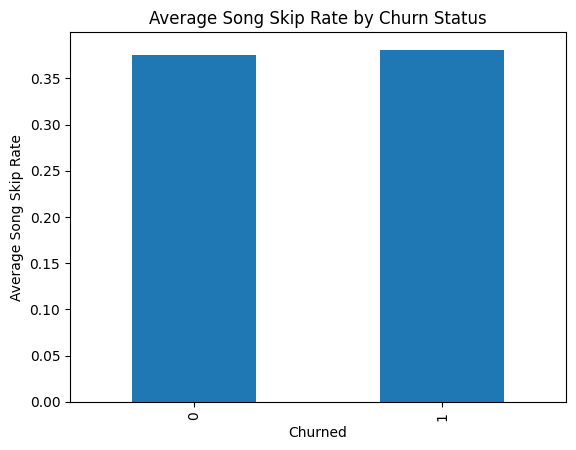

In [21]:
# Average skip rate by churn status
skip_rate_by_churn = df_clean.groupby("churned")["song_skip_rate"].mean()

print(skip_rate_by_churn)

skip_rate_by_churn.plot(kind="bar")

plt.title("Average Song Skip Rate by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Average Song Skip Rate")

plt.show()

## Early Insight 3

Song skip rate was slightly higher among churned users than retained users. This suggests skip behavior may have some relationship with churn, but the difference is much smaller than the gap observed for payment plan, so it may be a weaker standalone predictor.

churned
0    64.560537
1    68.429519
Name: notifications_clicked, dtype: float64


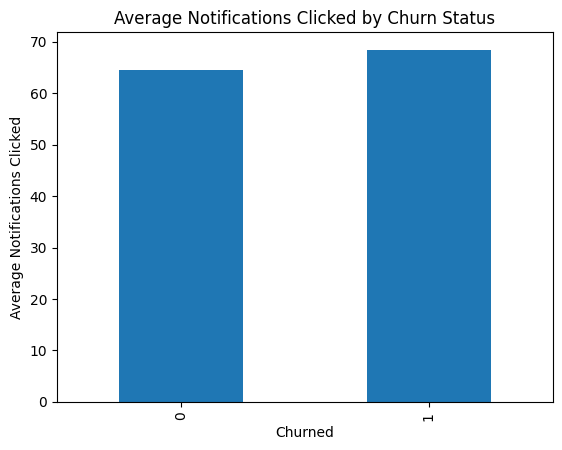

In [22]:
# Average notifications clicked by churn status
notifications_by_churn = df_clean.groupby("churned")["notifications_clicked"].mean()

print(notifications_by_churn)

notifications_by_churn.plot(kind="bar")

plt.title("Average Notifications Clicked by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Average Notifications Clicked")

plt.show()

## Early Insight 4

Users who churned clicked slightly more notifications on average than retained users. This suggests that notification interaction alone may not be a reliable signal of healthy retention. In a product context, it may reflect reactive engagement or re-engagement efforts rather than long-term loyalty.

churned
0    11.847332
1    11.918601
Name: num_playlists_created, dtype: float64


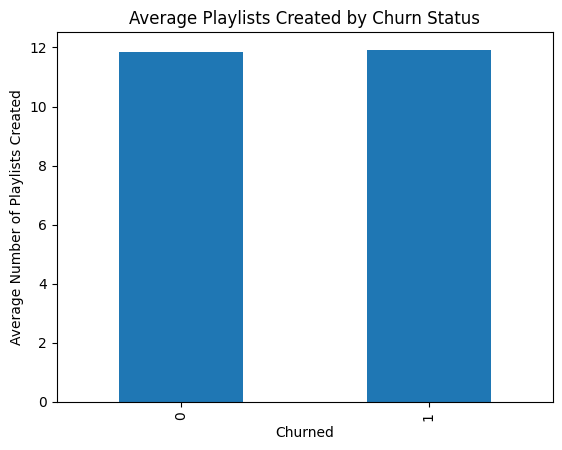

In [23]:
# Average playlists created by churn status
playlists_by_churn = df_clean.groupby("churned")["num_playlists_created"].mean()

print(playlists_by_churn)

playlists_by_churn.plot(kind="bar")

plt.title("Average Playlists Created by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Average Number of Playlists Created")

plt.show()

## Early Insight 5

The average number of playlists created was nearly identical for churned and retained users. This suggests that playlist creation alone does not strongly separate users who leave from those who stay in this dataset.

customer_service_inquiries
none    0.215882
many    0.214079
some    0.212662
few     0.211864
Name: churned, dtype: float64


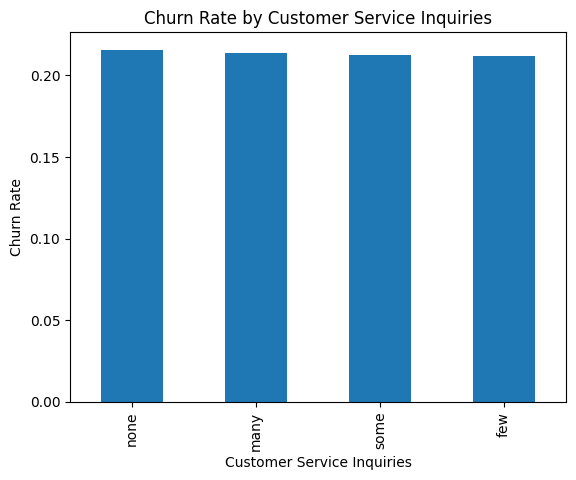

In [24]:
# Churn rate by inquiry level
churn_by_inquiries = df_clean.groupby("customer_service_inquiries")["churned"].mean().sort_values(ascending=False)

print(churn_by_inquiries)

churn_by_inquiries.plot(kind="bar")

plt.title("Churn Rate by Customer Service Inquiries")
plt.xlabel("Customer Service Inquiries")
plt.ylabel("Churn Rate")

plt.show()

## Early Insight 6

Customer service inquiry level showed very little variation in churn rate across categories. This suggests that support-contact frequency is not a strong standalone churn signal in this dataset.


## Key Findings

The early exploratory analysis suggests that churn in this dataset is driven more by account structure than by simple top-line engagement metrics. Weekly listening hours, average session length, and playlist creation were all very similar between churned and retained users. Song skip rate was slightly higher among churned users, but the difference was modest. In contrast, subscription type and especially payment plan showed much larger differences in churn rates. Monthly users churned far more often than annual users, making payment structure one of the strongest early signals in the dataset.

## Modeling Setup

After the exploratory analysis, the data was prepared for modeling by dropping identifier fields, separating features from the target variable, and splitting the dataset into training and testing sets. Categorical variables were encoded using one-hot encoding, while numeric variables were passed through a preprocessing pipeline.

In [25]:
# Drop customer_id because it is only an identifier, not a real predictive feature
df_model = df_clean.drop(columns=["customer_id"])

df_model.head()

,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,signup_date,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,tenure_days
0,72,Washington,family premium,monthly,monthly,venmo,many,2014-04-08,17.953071,2.453398,0.04,245,151,35,57,14,7,0,0,2870
1,48,New York,family premium,annual,monthly,credit,none,2015-12-10,7.725493,0.924008,0.98,112,57,18,62,10,3,1,0,2259
2,76,West Virginia,family premium,annual,annual,credit,few,2014-04-22,9.514800,1.563817,0.35,124,96,15,34,17,6,1,0,2856
3,80,Georgia,family premium,annual,annual,debit,few,2013-08-31,8.497869,1.089721,0.69,130,109,13,42,8,4,0,0,3090
4,39,New Jersey,family premium,annual,annual,debit,many,2013-01-14,29.971731,2.313365,0.76,490,293,54,90,14,5,0,0,3319


In [26]:
print(df_model.columns.tolist())

['age', 'location', 'subscription_type', 'payment_plan', 'num_subscription_pauses', 'payment_method', 'customer_service_inquiries', 'signup_date', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'churned', 'tenure_days']


In [27]:
# Drop signup_date because we already converted it into tenure_days
df_model = df_model.drop(columns=["signup_date"])

# Check the remaining columns
print(df_model.columns.tolist())

['age', 'location', 'subscription_type', 'payment_plan', 'num_subscription_pauses', 'payment_method', 'customer_service_inquiries', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'churned', 'tenure_days']


In [28]:
# Define target and features
target = "churned"
X = df_model.drop(columns=[target])
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41000, 18)
y shape: (41000,)


In [29]:
print("Numeric columns:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Numeric columns:
['age', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'tenure_days']

Categorical columns:
['location', 'subscription_type', 'payment_plan', 'num_subscription_pauses', 'payment_method', 'customer_service_inquiries']


In [30]:
from sklearn.model_selection import train_test_split

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (32800, 18)
X_test shape: (8200, 18)
y_train shape: (32800,)
y_test shape: (8200,)


In [31]:
print("Training churn proportion:")
print(y_train.value_counts(normalize=True))

print("\nTesting churn proportion:")
print(y_test.value_counts(normalize=True))

Training churn proportion:
churned
0    0.786646
1    0.213354
Name: proportion, dtype: float64

Testing churn proportion:
churned
0    0.786707
1    0.213293
Name: proportion, dtype: float64


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [34]:
# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [36]:
# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

categorical_transformer

Numeric features:
['age', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'tenure_days']

Categorical features:
['location', 'subscription_type', 'payment_plan', 'num_subscription_pauses', 'payment_method', 'customer_service_inquiries']


In [37]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['age', 'weekly_hours',
                                  'average_session_length', 'song_skip_rate',
                                  'weekly_songs_played', 'weekly_unique_songs',
                                  'num_favorite_artists',
                                  'num_platform_friends',
                                  'num_playlists_created',
                                  'num_shared_playlists',
                                  'notifications_clicked', 'tenure_days']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['location', 'subscription_type',
                                  'payment_plan', 'num_subscription_pauses',
                                  'payment_method',
                                  'customer_service_inquiries'])])

In [ ]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor

## Model Training and Evaluation

Two baseline models were trained and compared: a balanced logistic regression model and a random forest classifier. The goal was not only to evaluate overall accuracy, but also to assess how well each model identified churned users in a retention-focused setting.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [40]:
# Balanced logistic regression
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      6451
           1       0.36      0.47      0.40      1749

    accuracy                           0.71      8200
   macro avg       0.60      0.62      0.60      8200
weighted avg       0.74      0.71      0.72      8200

ROC-AUC: 0.6321528904308231


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Balanced Logistic Regression Interpretation

Adding class balancing significantly improved the model’s ability to identify churned users. Recall for the churned class increased from near zero to 0.47, showing that the model became much better at catching at-risk users. This came at the cost of lower overall accuracy and lower precision for churn predictions, which is expected in an imbalanced classification problem. For a churn use case, this tradeoff is often acceptable because missing true churners can be more costly than flagging some users who would have stayed.


In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
# Random forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.80      0.97      0.88      6451
           1       0.51      0.13      0.20      1749

    accuracy                           0.79      8200
   macro avg       0.66      0.55      0.54      8200
weighted avg       0.74      0.79      0.73      8200

ROC-AUC: 0.6442699635081685


## Model Comparison

Two baseline models were compared: a balanced logistic regression and a random forest classifier. The random forest produced slightly higher overall accuracy and ROC-AUC, but it identified only a small portion of users who actually churned. The balanced logistic regression captured a much larger share of churned users, making it more practical for a retention use case. In a churn setting, recall for the positive class is especially important because failing to identify at-risk users can reduce the effectiveness of intervention strategies.

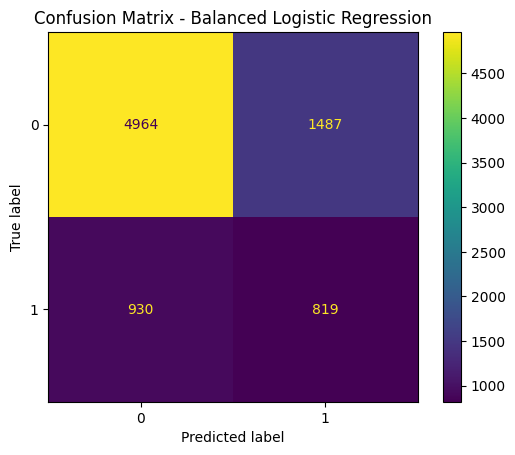

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix for the balanced logistic regression model
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

## Confusion Matrix Interpretation

The balanced logistic regression model identifies a meaningful share of churned users, although it also produces false positives. This tradeoff is acceptable in a churn prediction setting where the main goal is to flag at-risk users early enough for intervention.

## Business Recommendations

This analysis suggests that churn is more strongly associated with account structure than with simple listening-volume metrics. Monthly users and certain subscription types showed notably higher churn rates, making them strong candidates for targeted retention efforts.

Recommended actions:
- prioritize retention campaigns for monthly subscribers
- test incentives for high-risk subscription segments such as student users
- monitor churn risk using a combination of account and behavioral features rather than relying only on top-line engagement
- use churn scores to support re-engagement messaging, renewal offers, or targeted product nudges

## Final Conclusion

The project found that payment structure and subscription type were among the strongest early indicators of churn, while several simple engagement metrics showed limited separation between churned and retained users. Among the two models tested, balanced logistic regression was more useful for a churn-management use case because it identified a much larger share of churned users. These results suggest that retention strategies should focus on higher-risk subscriber segments and use predictive modeling as a support tool for targeted intervention.